In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

In [9]:
# filtros
def bandpass(x, lo, hi, order=4):
    nyq = FS / 2
    b, a = signal.butter(order, [lo/nyq, hi/nyq], btype='band')
    return signal.filtfilt(b, a, x)

def notch(x, f0=60, Q=30):
    b, a = signal.iirnotch(f0 / (FS/2), Q)
    return signal.filtfilt(b, a, x)

In [10]:
BANDS = {
    'Delta (0.5–4 Hz)' : (0.5, 4,  '#7b68ee'),
    'Theta (4–8 Hz)'   : (4,   8,  '#00bfff'),
    'Alpha (8–13 Hz)'  : (8,   13, '#00ff88'),
    'Beta (13–30 Hz)'  : (13,  30, '#ff6b35'),
    'Gamma (30–45 Hz)' : (30,  45, '#ff1493'),
}

Duración : 64.05 s
Rango    : -27.23 – 35.09 µV


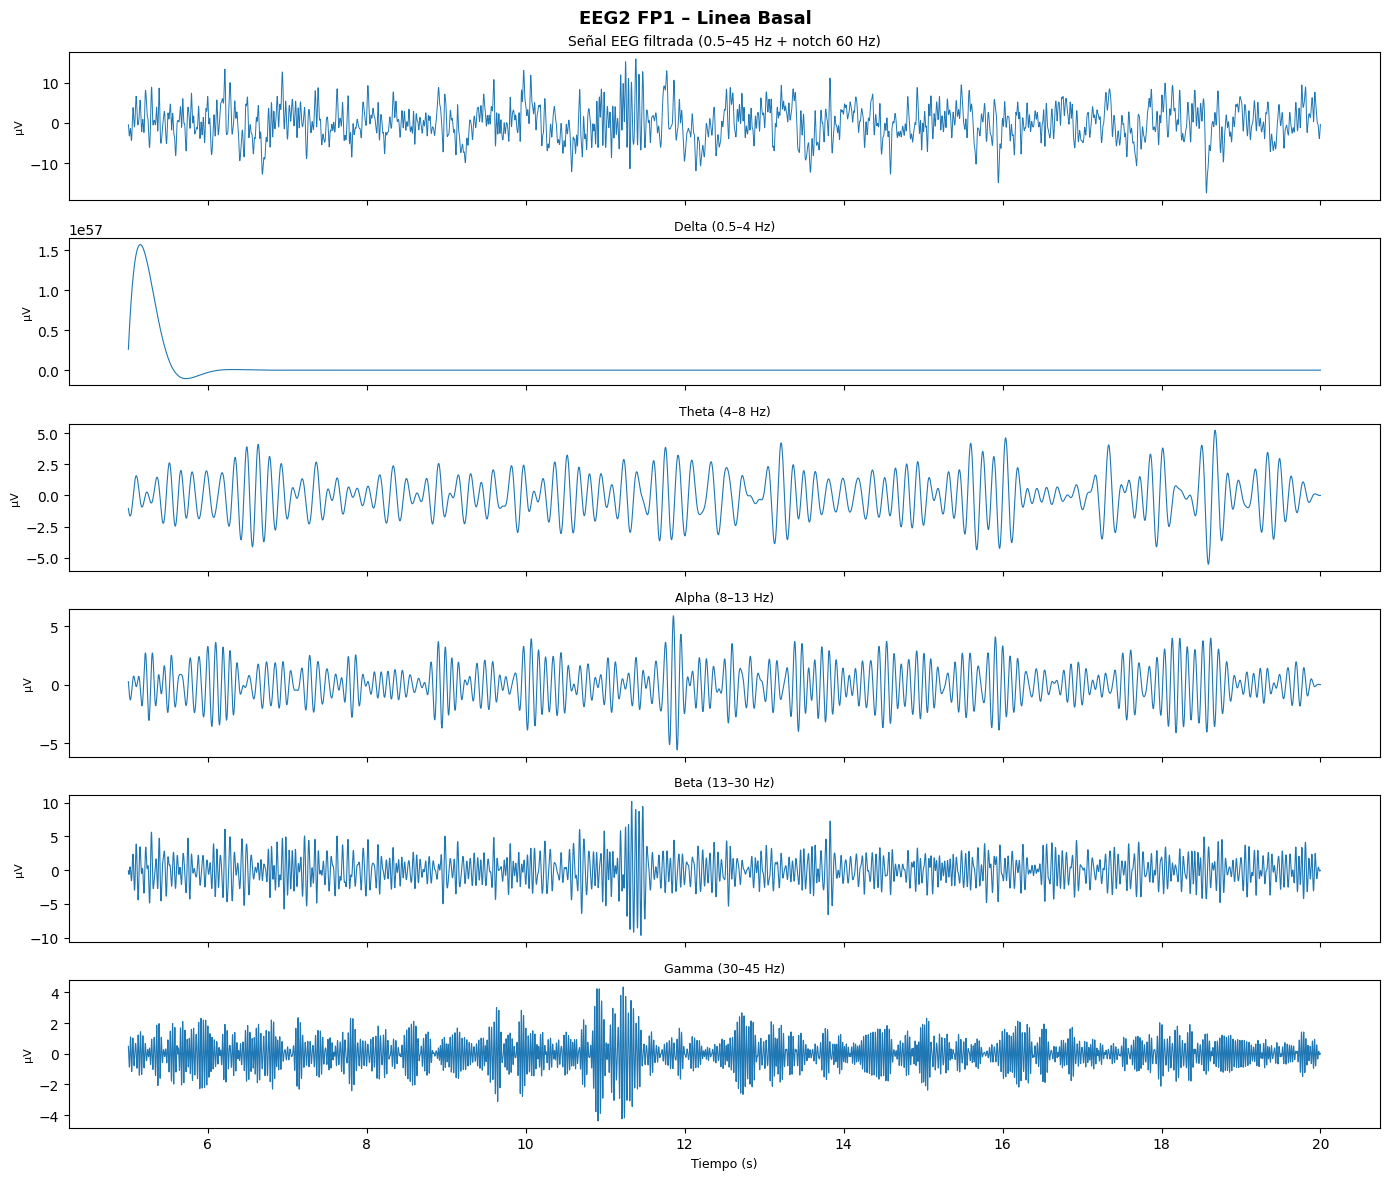

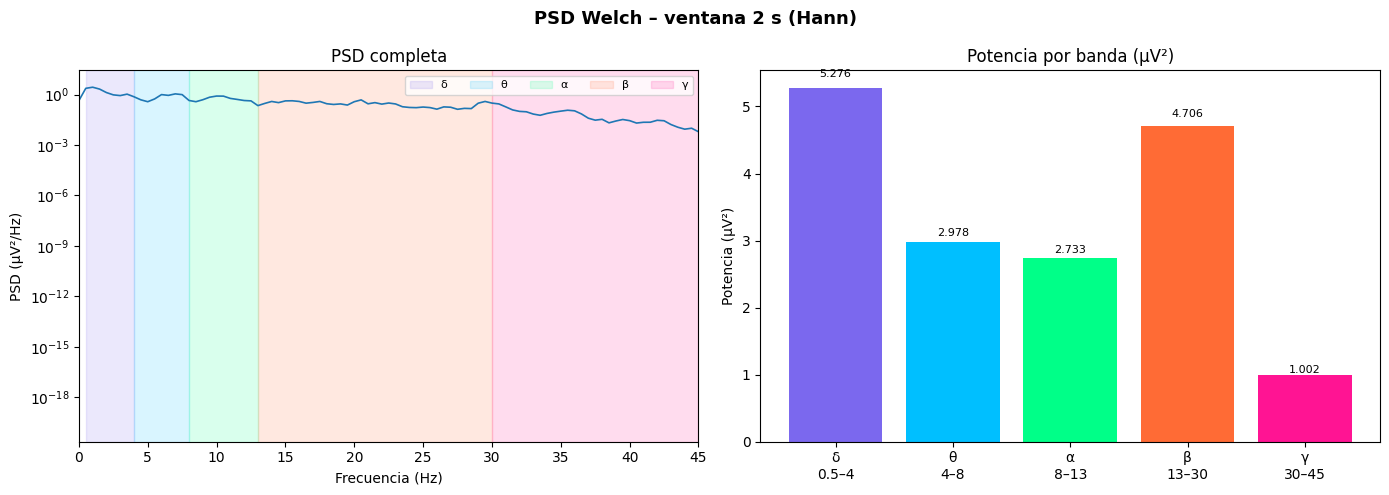

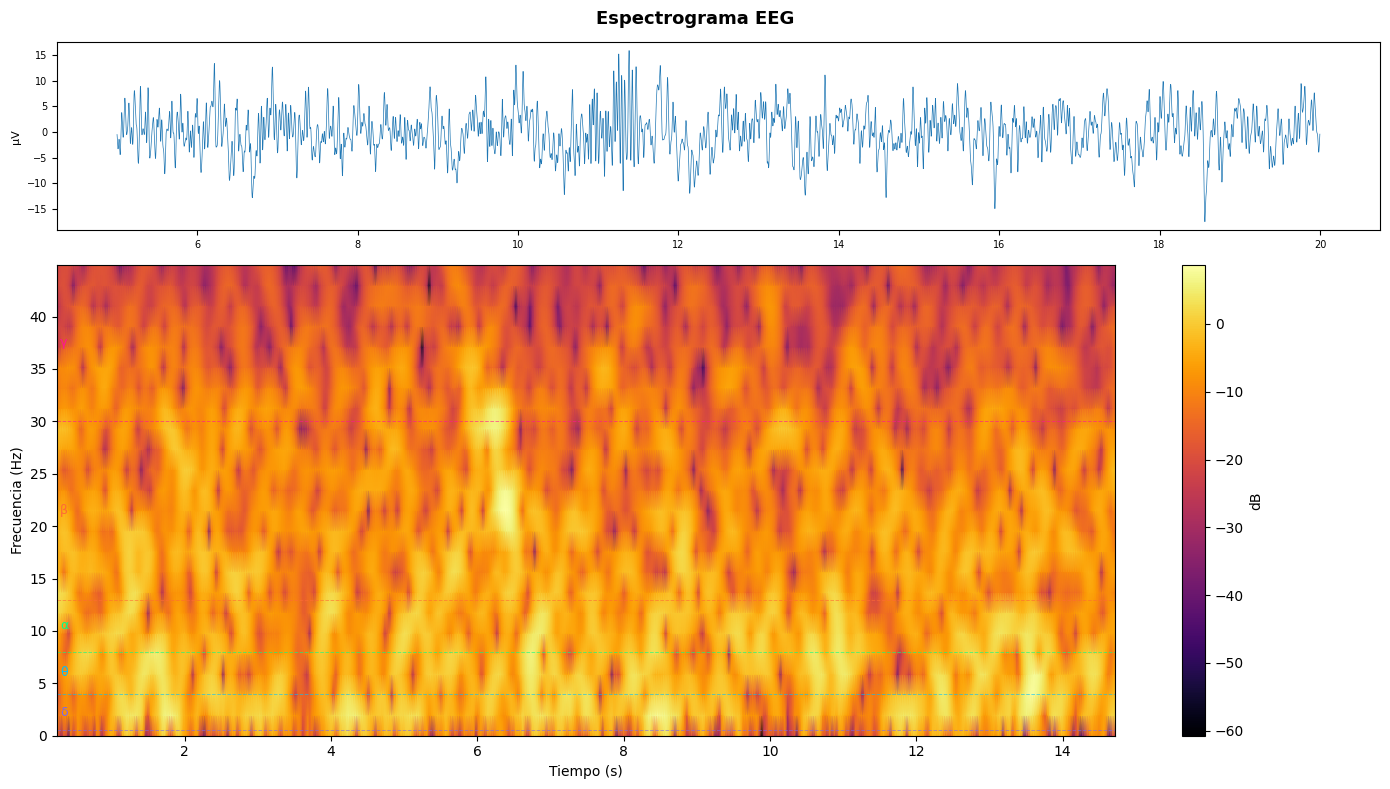

  RESUMEN – EEG2 Linea Basal
  Duración        : 20.00 s
  Rango señal     : -17.45 – 15.83 µV

  Delta (0.5–4 Hz)      : 5.2755 µV²  (31.6%)
  Theta (4–8 Hz)        : 2.9779 µV²  (17.8%)
  Alpha (8–13 Hz)       : 2.7332 µV²  (16.4%)
  Beta (13–30 Hz)       : 4.7057 µV²  (28.2%)
  Gamma (30–45 Hz)      : 1.0022 µV²  (6.0%)


In [18]:
# EEG2 - Linea Basal

ARCHIVO   = "EEG2_lineabasal1minuto.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 5
t_end   = 20

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG2 FP1 – Linea Basal', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2 Linea Basal")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 57.52 s
Rango    : -39.41 – 39.03 µV


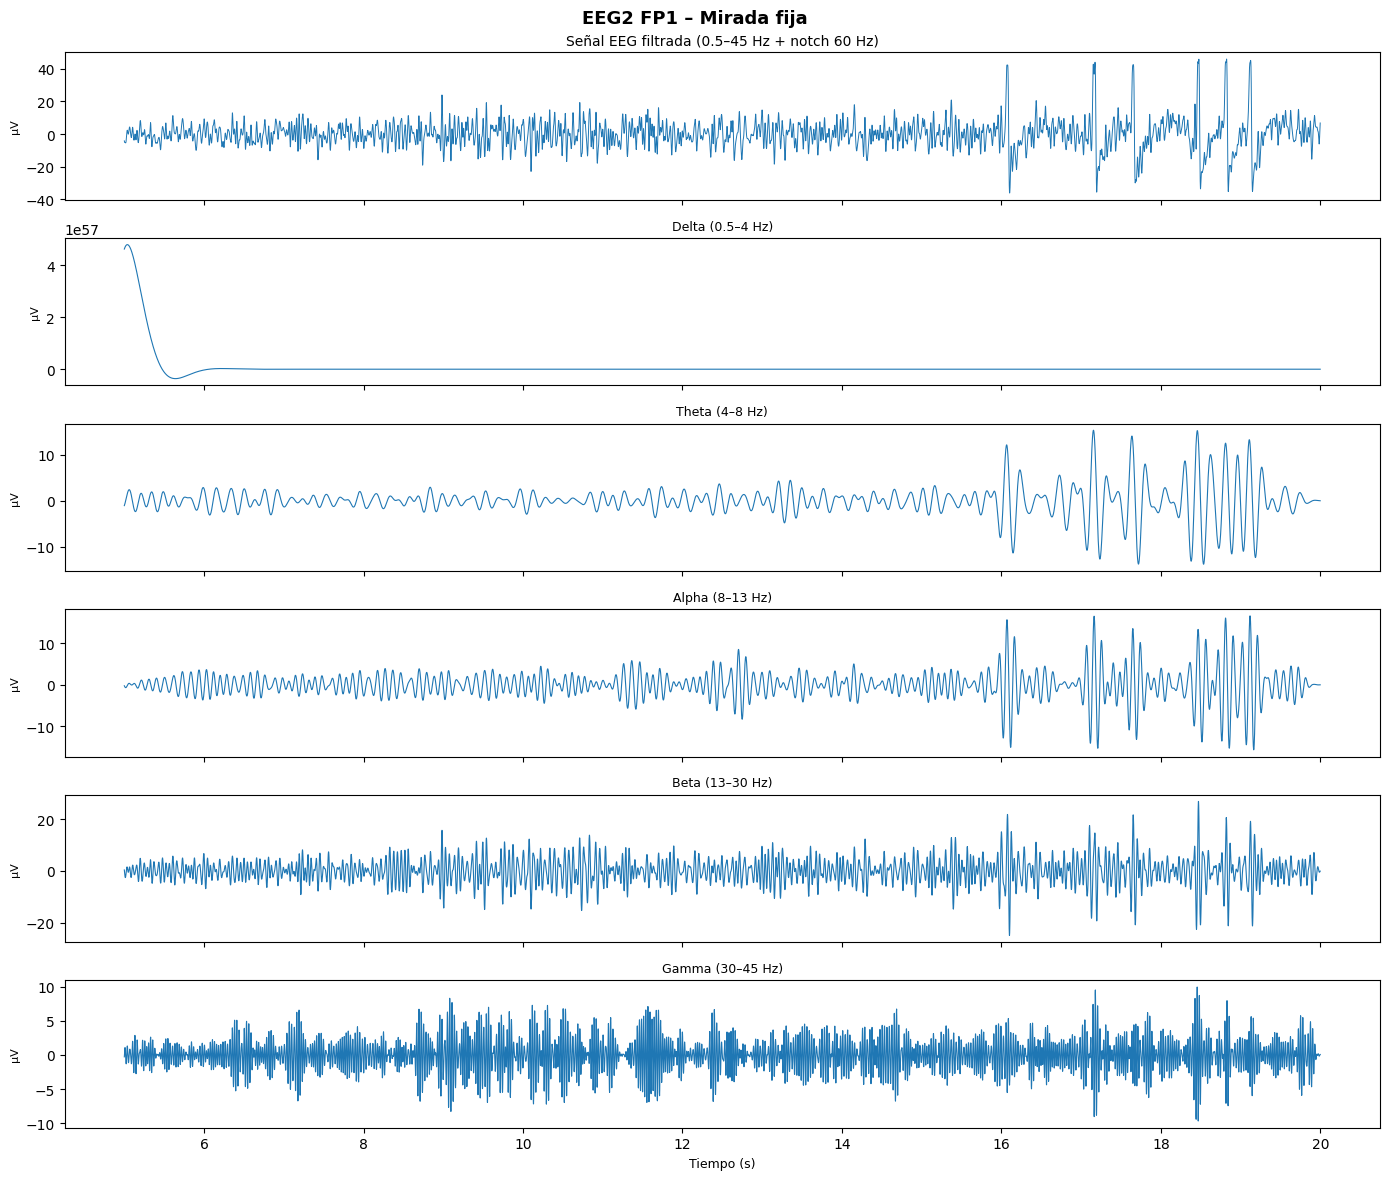

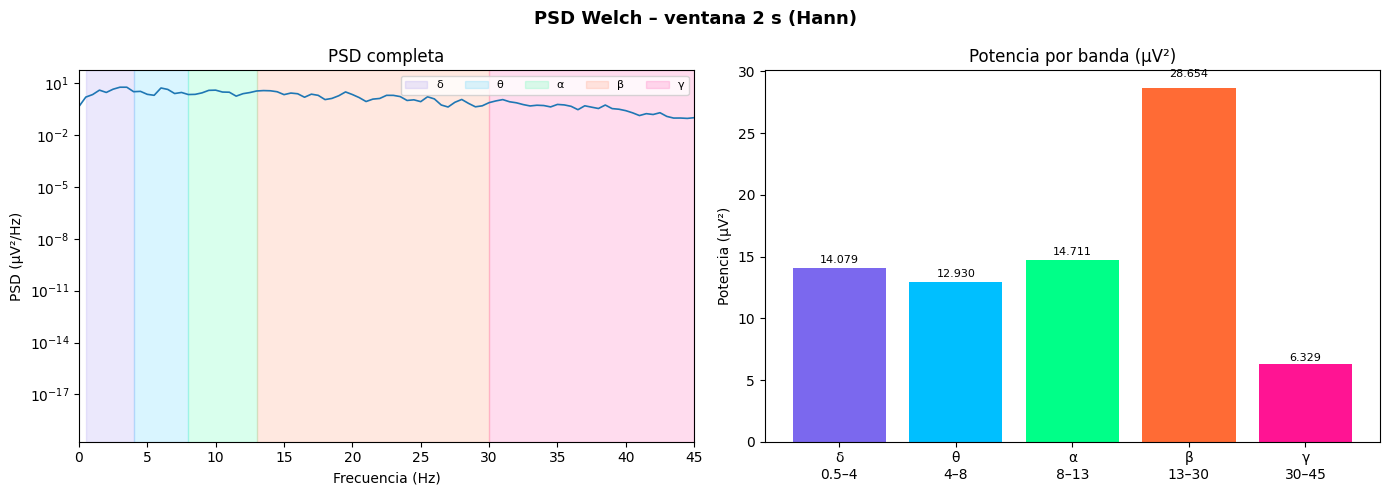

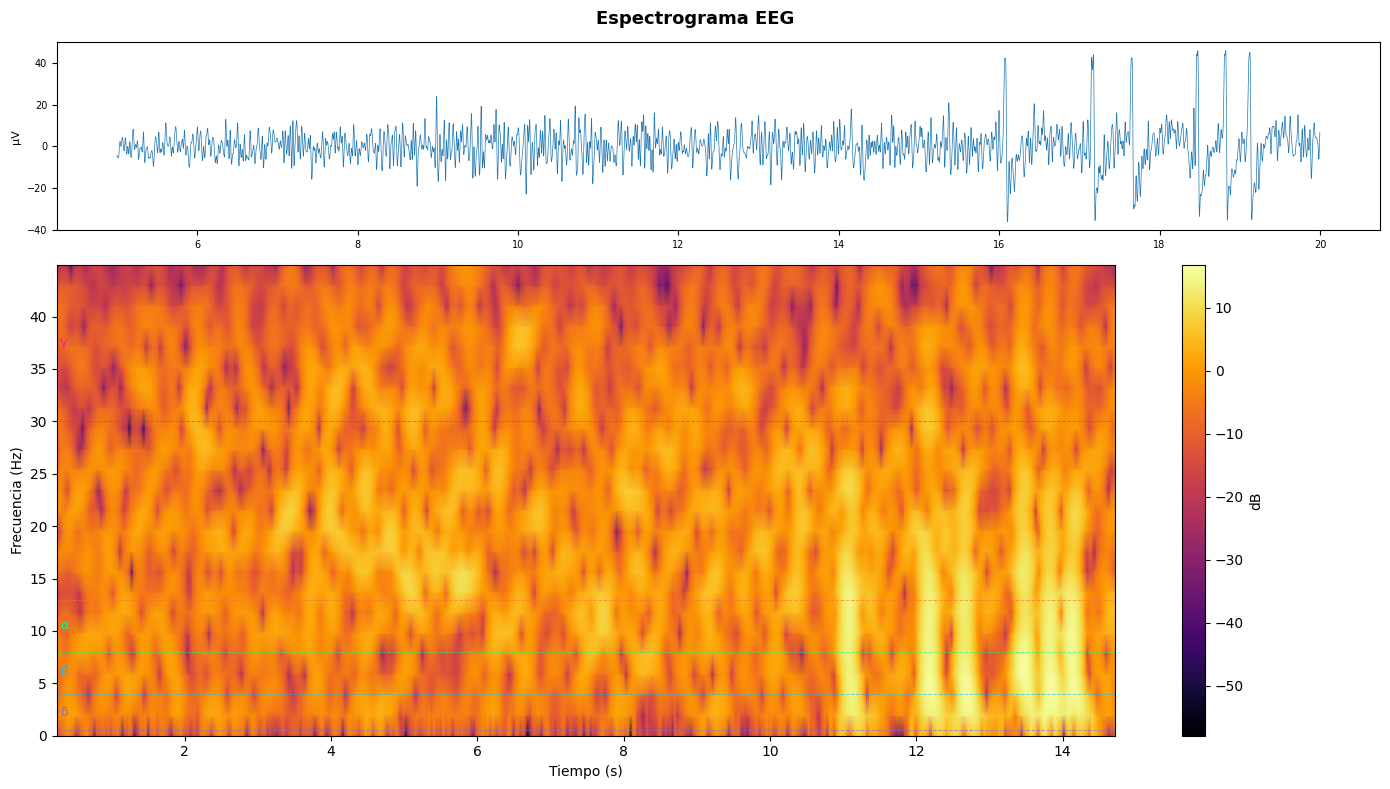

  RESUMEN – EEG2 Mirada fija
  Duración        : 20.00 s
  Rango señal     : -36.12 – 45.90 µV

  Delta (0.5–4 Hz)      : 14.0792 µV²  (18.4%)
  Theta (4–8 Hz)        : 12.9304 µV²  (16.9%)
  Alpha (8–13 Hz)       : 14.7108 µV²  (19.2%)
  Beta (13–30 Hz)       : 28.6543 µV²  (37.4%)
  Gamma (30–45 Hz)      : 6.3290 µV²  (8.3%)


In [19]:
ARCHIVO   = "EEG2_miradapuntofijo.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 5
t_end   = 20

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG2 FP1 – Mirada fija', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2 Mirada fija")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 44.65 s
Rango    : -39.41 – 39.03 µV


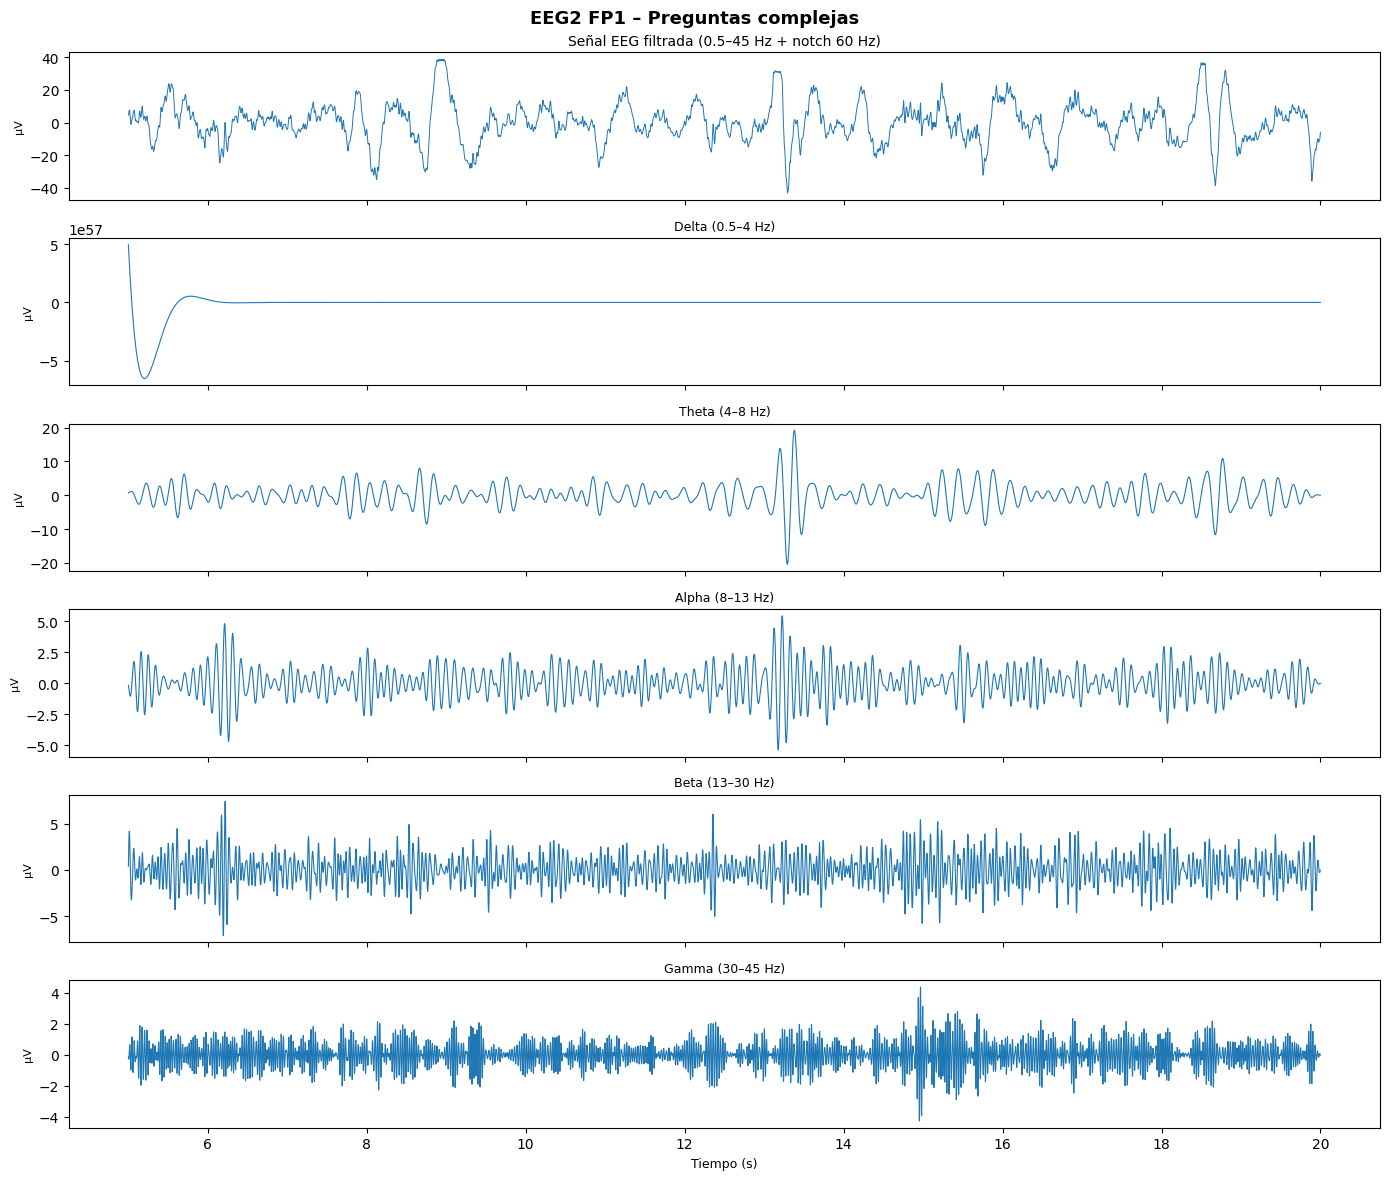

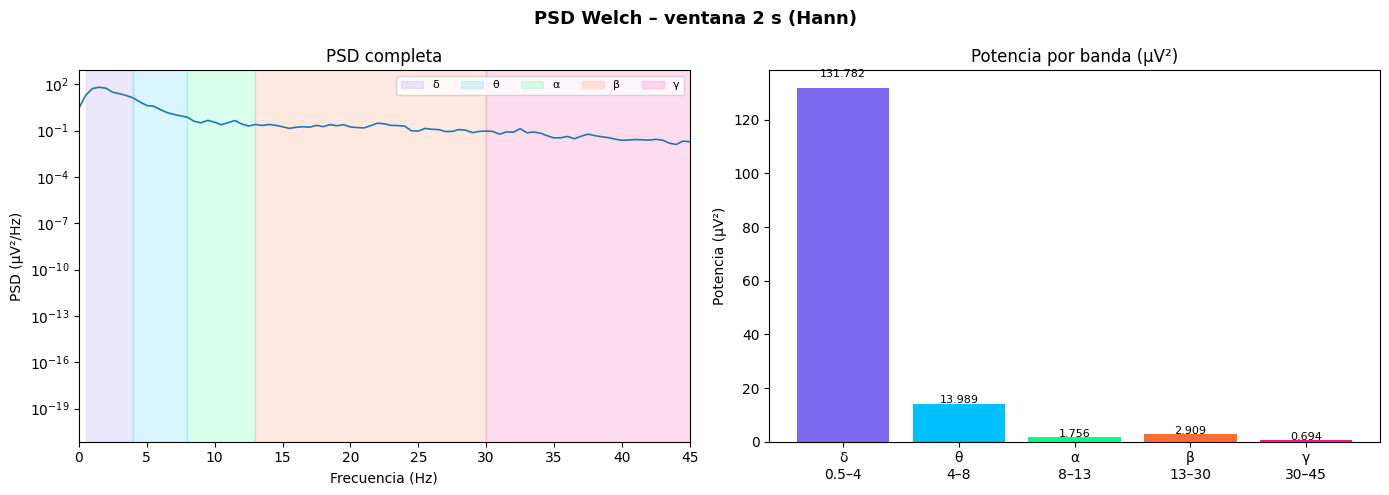

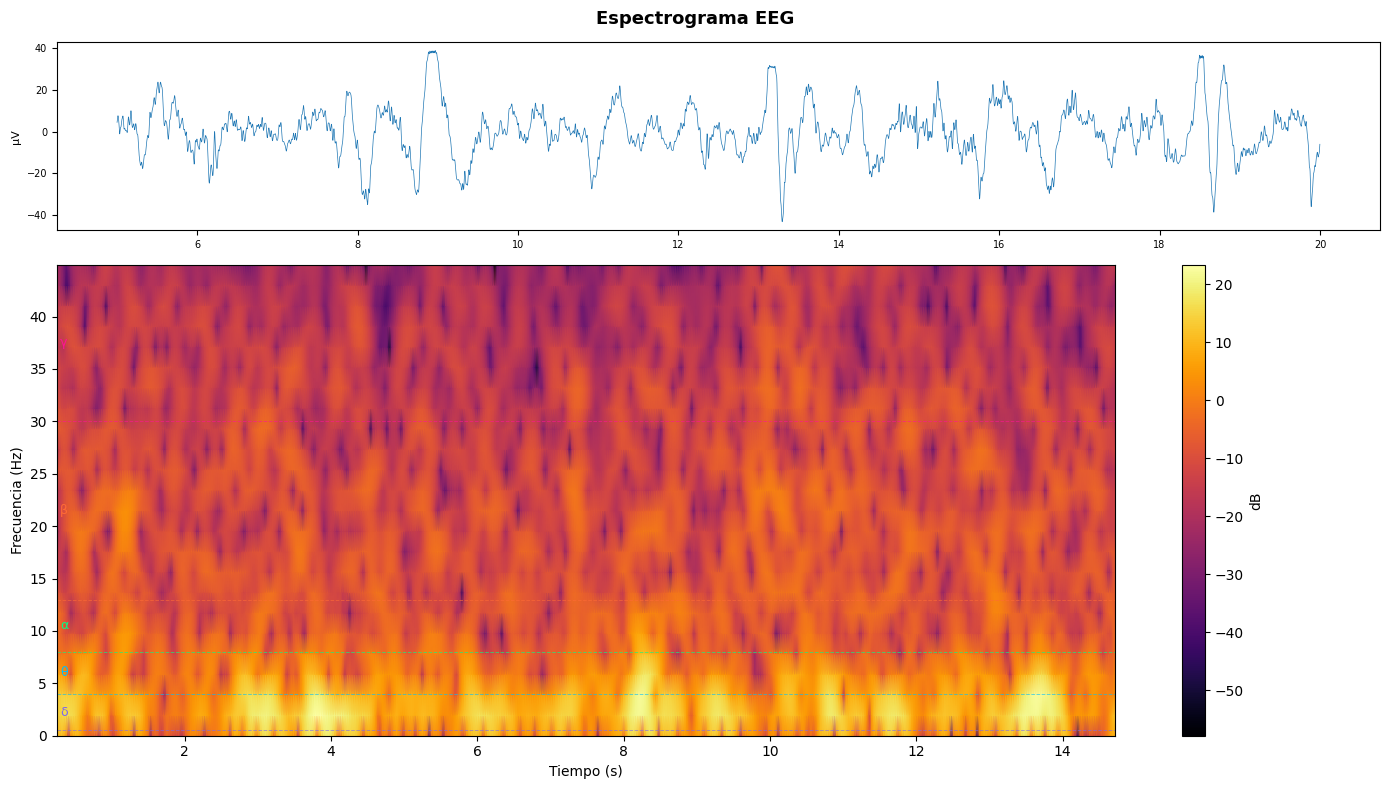

  RESUMEN – EEG2 Preguntas complejas
  Duración        : 20.00 s
  Rango señal     : -43.21 – 38.91 µV

  Delta (0.5–4 Hz)      : 131.7822 µV²  (87.2%)
  Theta (4–8 Hz)        : 13.9887 µV²  (9.3%)
  Alpha (8–13 Hz)       : 1.7557 µV²  (1.2%)
  Beta (13–30 Hz)       : 2.9090 µV²  (1.9%)
  Gamma (30–45 Hz)      : 0.6944 µV²  (0.5%)


In [20]:
ARCHIVO   = "EEG2_preguntascomplejas.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 5
t_end   = 20

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG2 FP1 – Preguntas complejas', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2 Preguntas complejas")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 35.36 s
Rango    : -39.41 – 39.03 µV


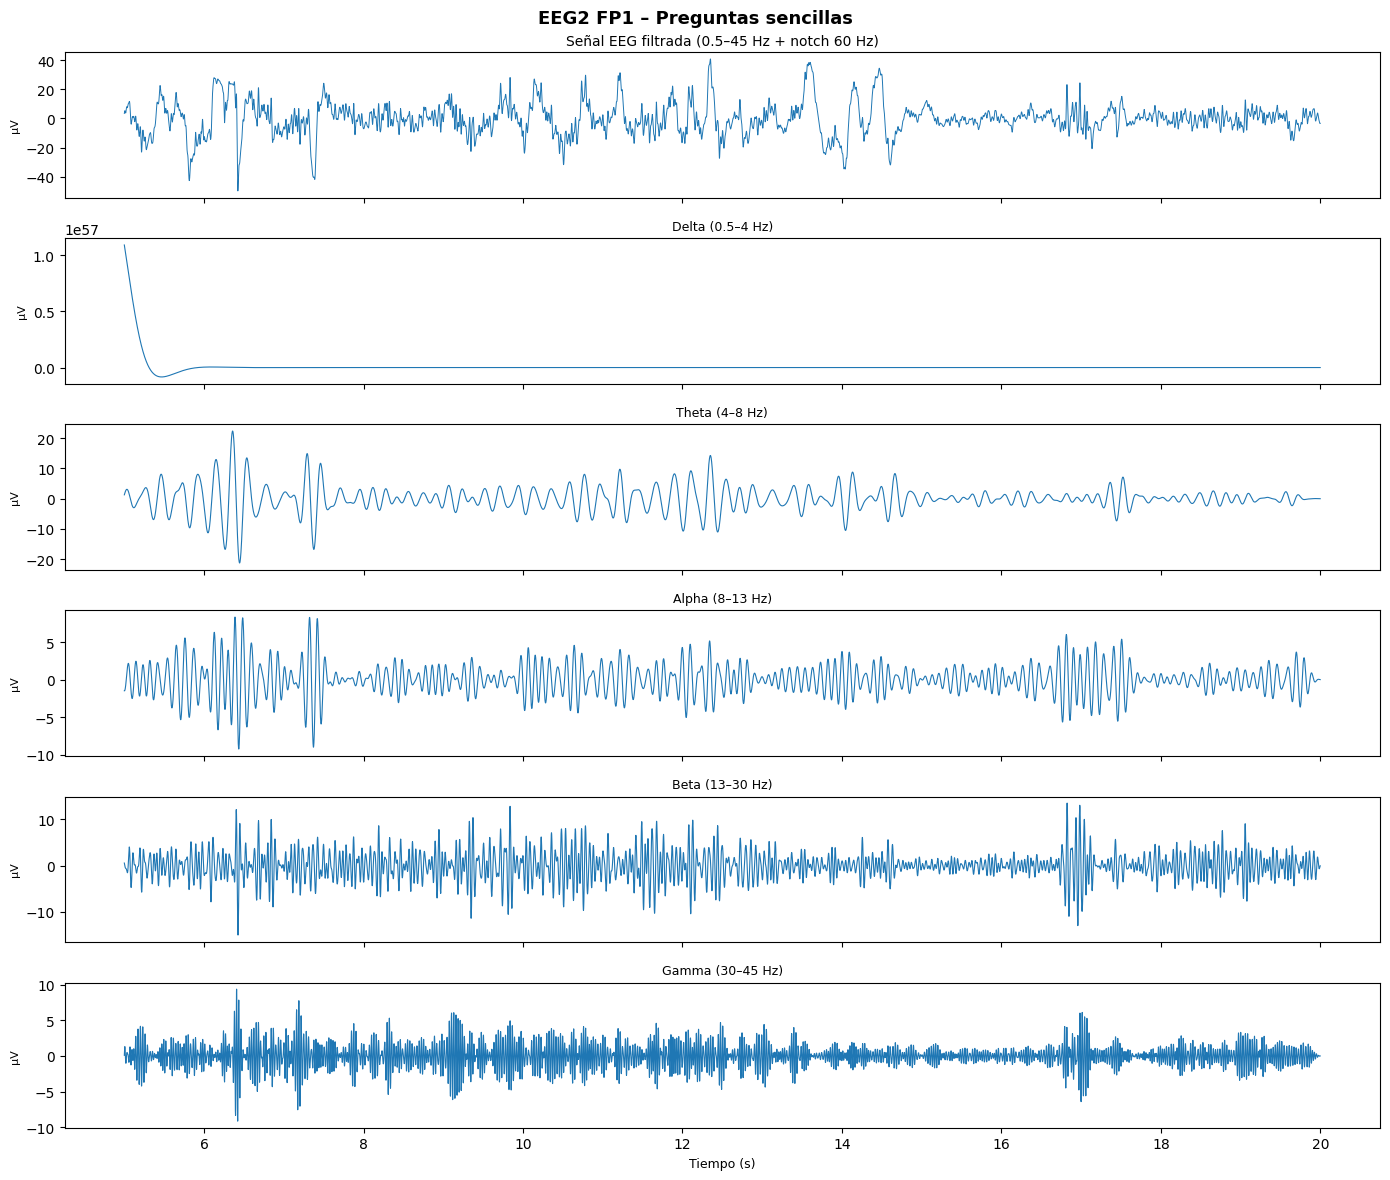

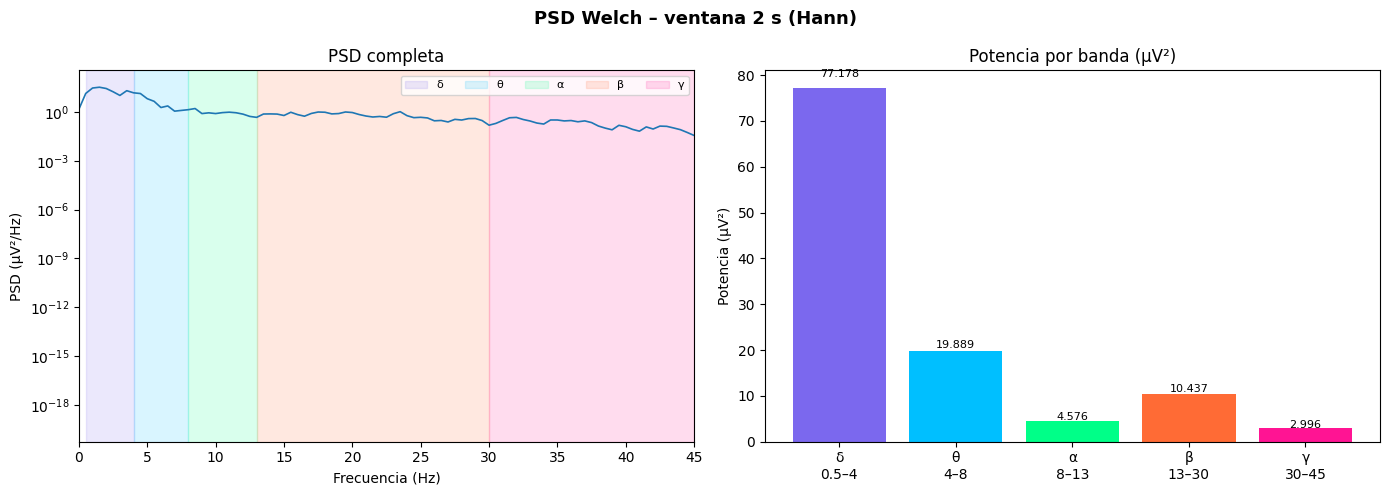

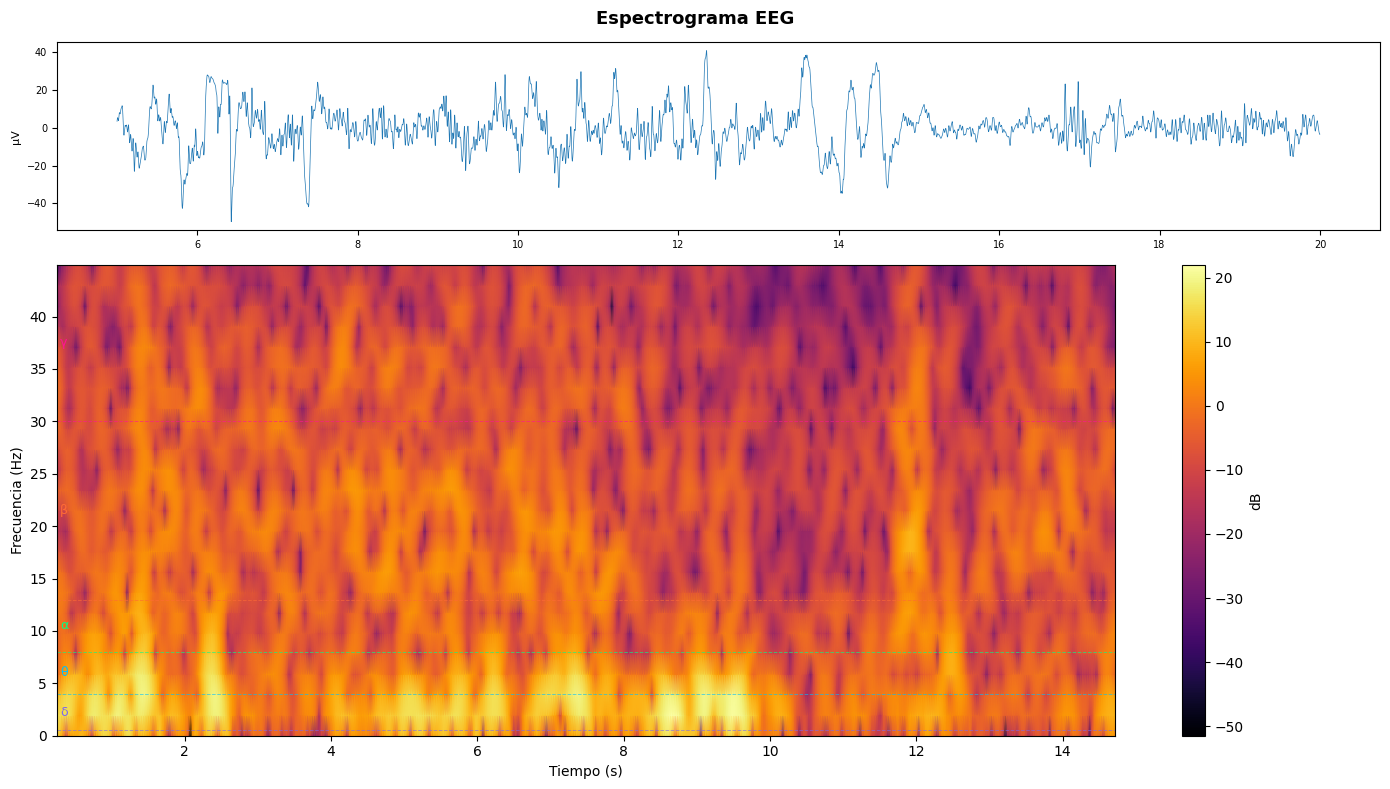

  RESUMEN – EEG2  preguntas sencillas
  Duración        : 20.00 s
  Rango señal     : -49.64 – 40.76 µV

  Delta (0.5–4 Hz)      : 77.1783 µV²  (67.1%)
  Theta (4–8 Hz)        : 19.8886 µV²  (17.3%)
  Alpha (8–13 Hz)       : 4.5759 µV²  (4.0%)
  Beta (13–30 Hz)       : 10.4368 µV²  (9.1%)
  Gamma (30–45 Hz)      : 2.9958 µV²  (2.6%)


In [21]:
ARCHIVO   = "EEG2_Preguntassencillas.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 5
t_end   = 20

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG2 FP1 – Preguntas sencillas', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2  preguntas sencillas")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 55.22 s
Rango    : -39.41 – 39.11 µV


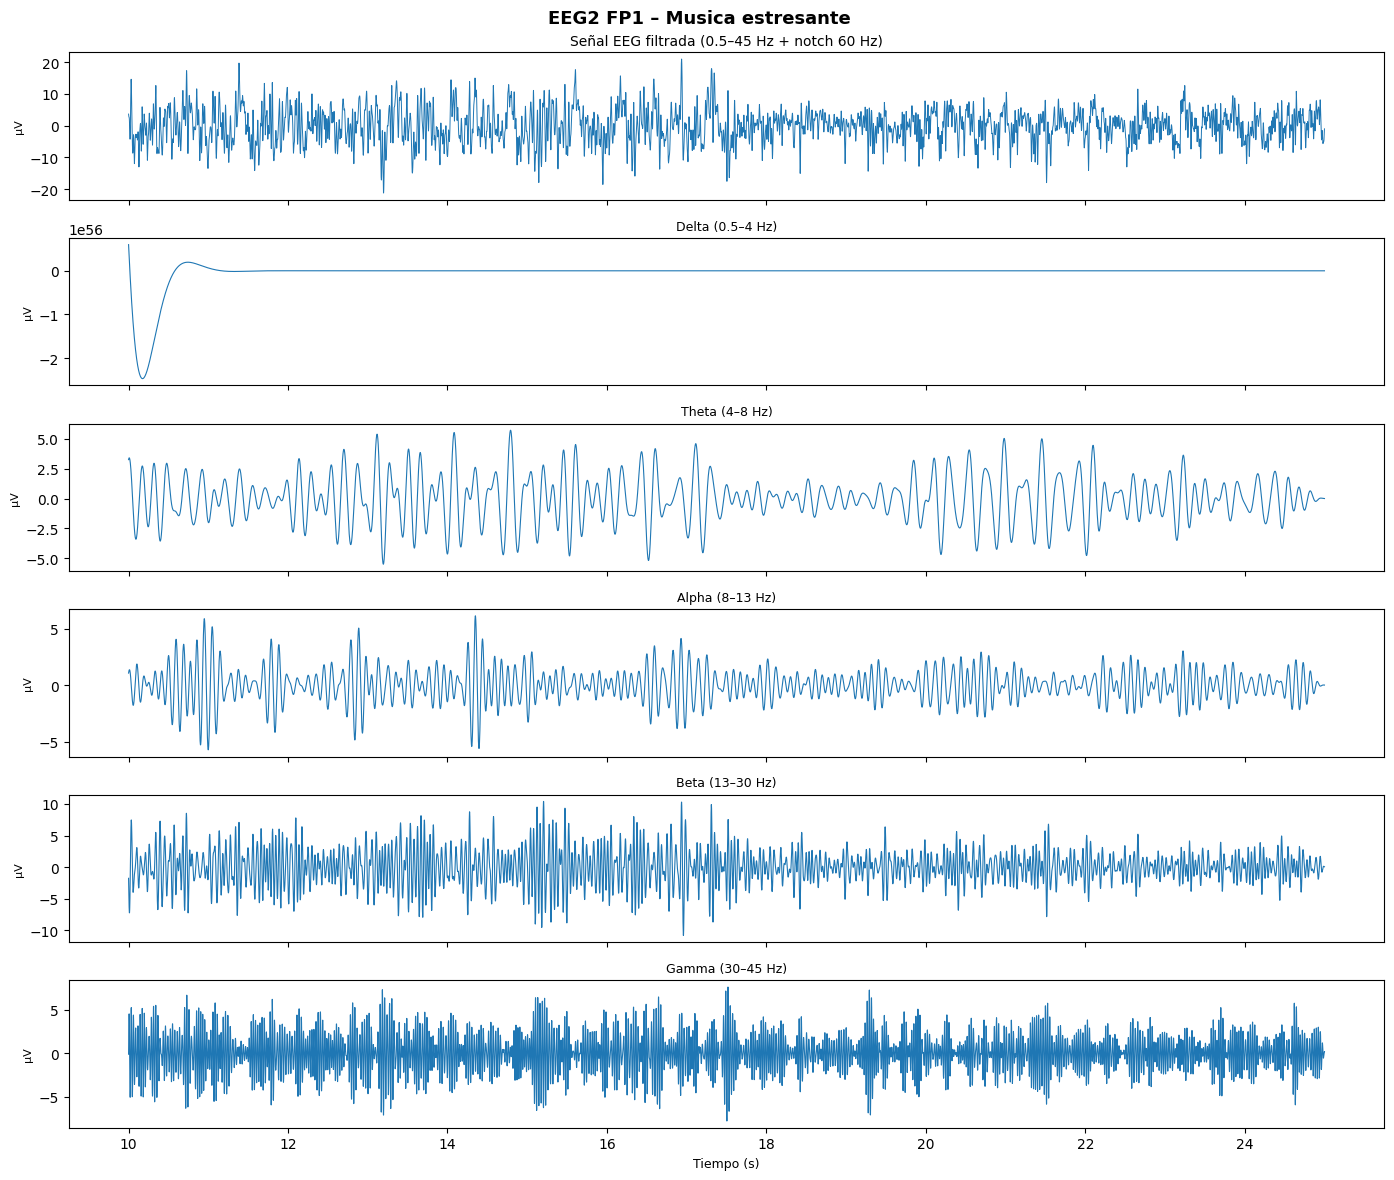

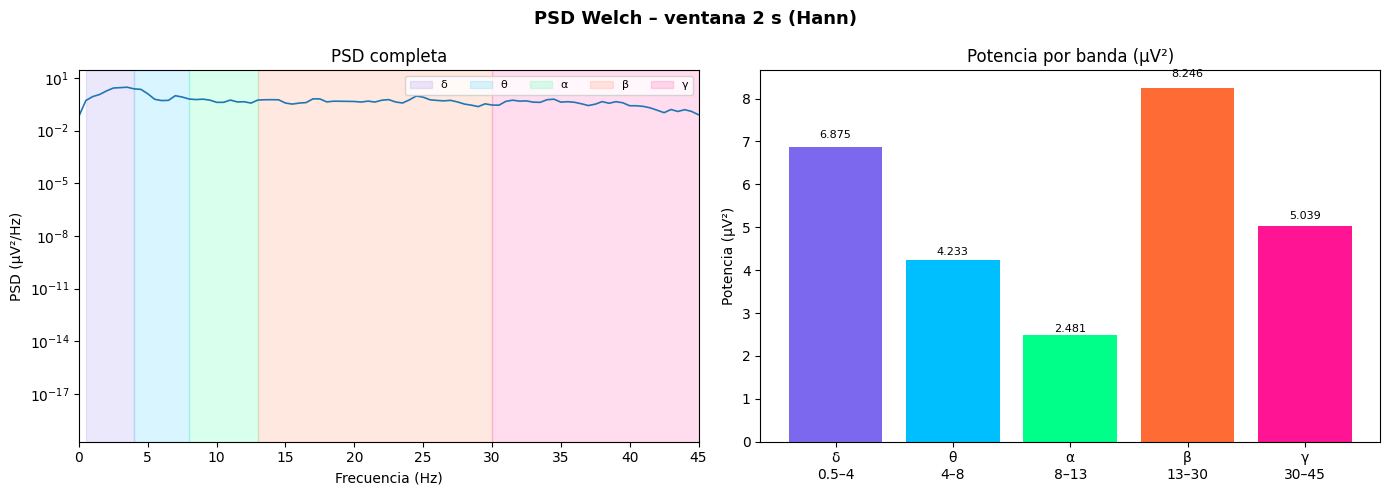

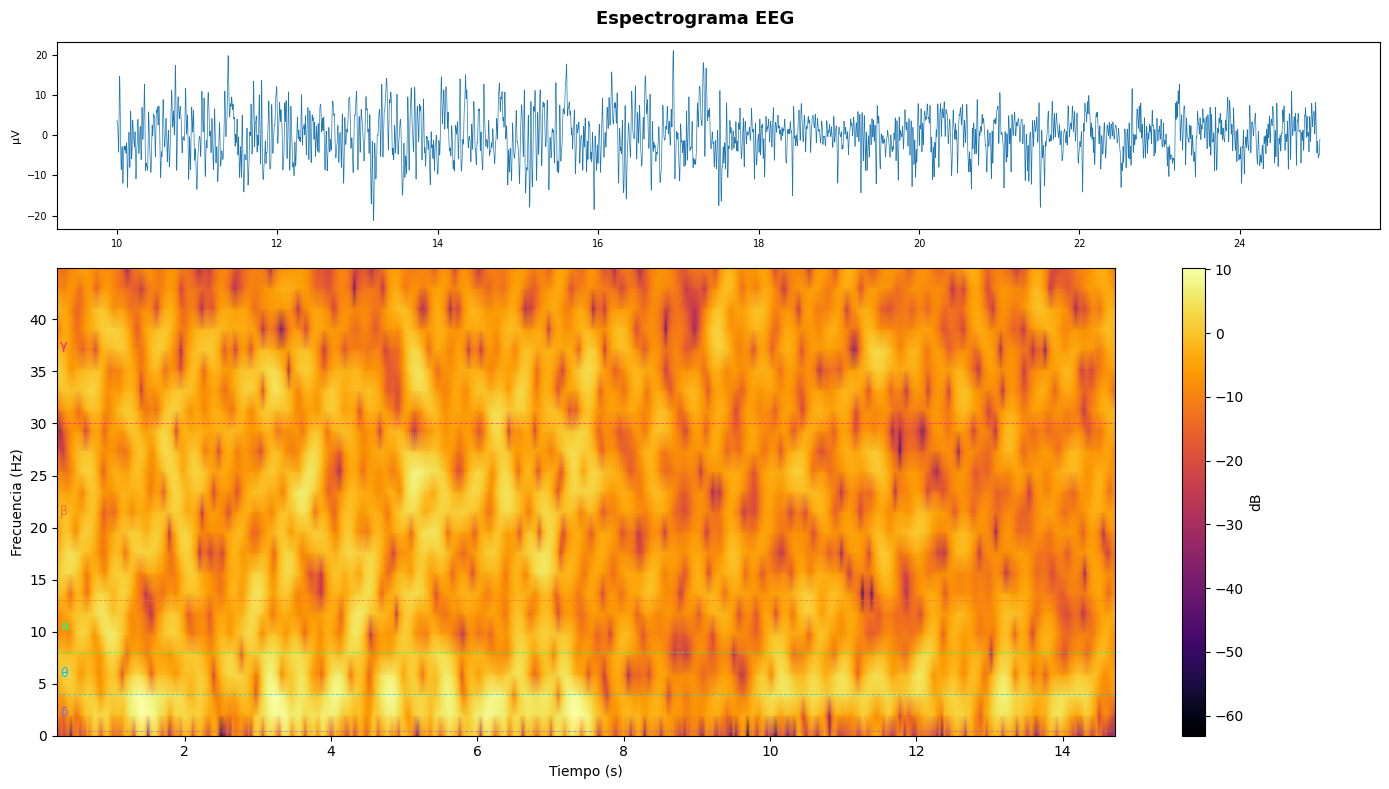

  RESUMEN – EEG2 musica estresante
  Duración        : 25.00 s
  Rango señal     : -21.23 – 21.00 µV

  Delta (0.5–4 Hz)      : 6.8753 µV²  (25.6%)
  Theta (4–8 Hz)        : 4.2328 µV²  (15.8%)
  Alpha (8–13 Hz)       : 2.4813 µV²  (9.2%)
  Beta (13–30 Hz)       : 8.2456 µV²  (30.7%)
  Gamma (30–45 Hz)      : 5.0389 µV²  (18.8%)


In [23]:
ARCHIVO   = "EEG2_musicaestresante.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 10
t_end   = 25

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG2 FP1 – Musica estresante', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2 musica estresante")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 66.23 s
Rango    : -39.41 – 39.03 µV


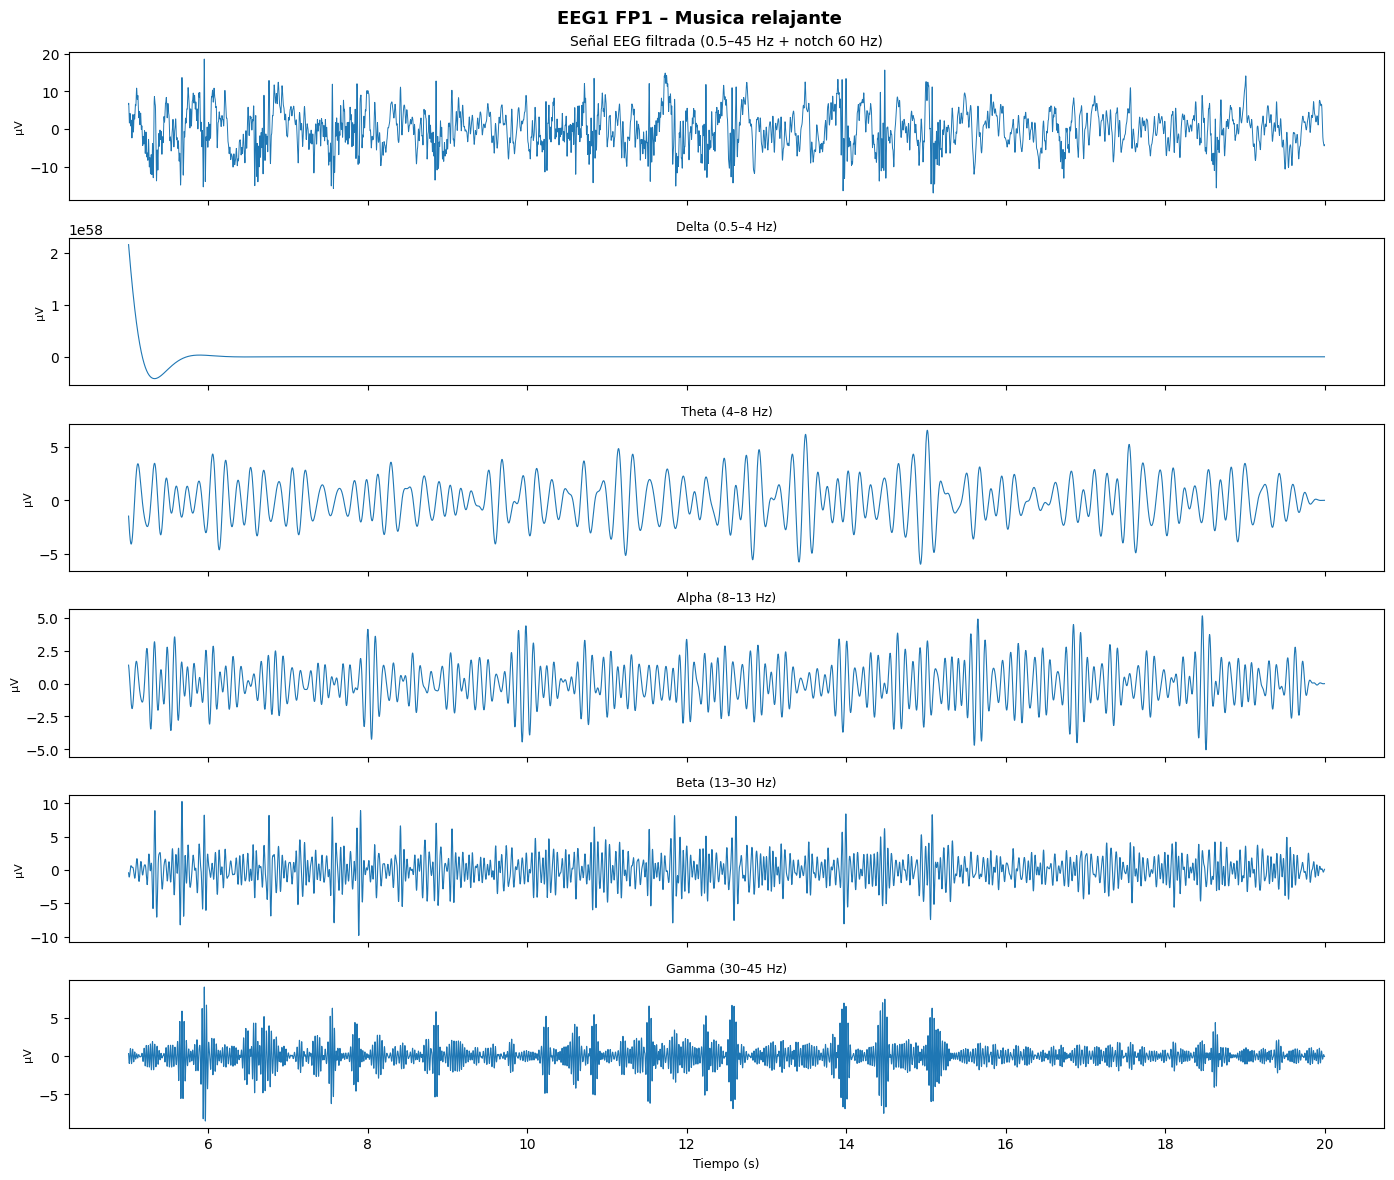

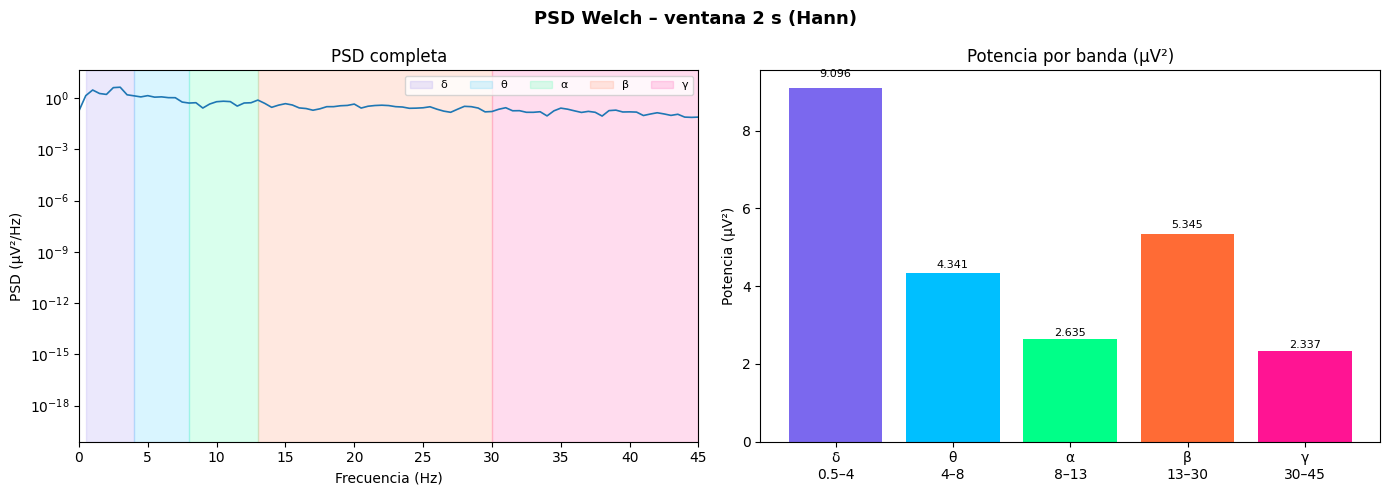

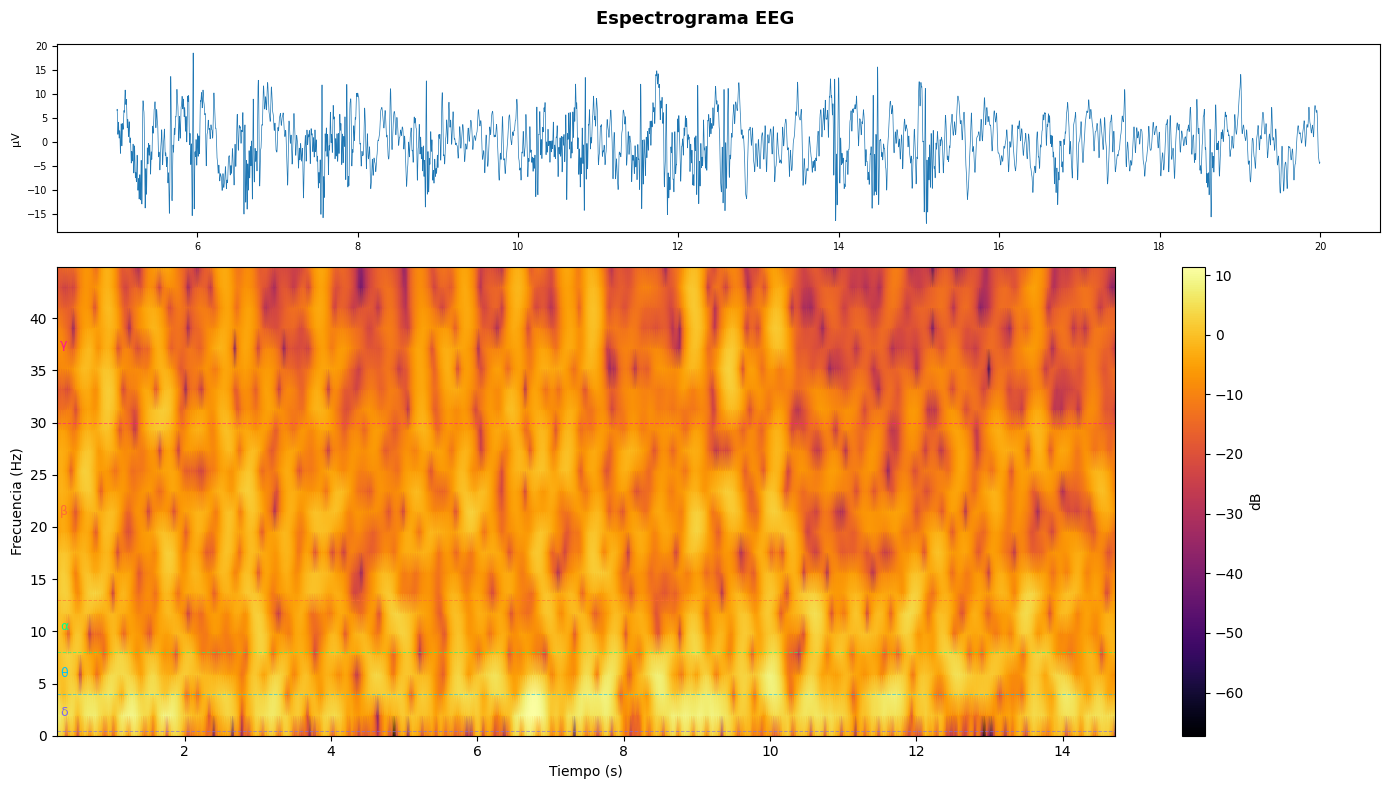

  RESUMEN – EEG2 musica relajante
  Duración        : 20.00 s
  Rango señal     : -17.05 – 18.60 µV

  Delta (0.5–4 Hz)      : 9.0956 µV²  (38.3%)
  Theta (4–8 Hz)        : 4.3410 µV²  (18.3%)
  Alpha (8–13 Hz)       : 2.6345 µV²  (11.1%)
  Beta (13–30 Hz)       : 5.3453 µV²  (22.5%)
  Gamma (30–45 Hz)      : 2.3371 µV²  (9.8%)


In [24]:
ARCHIVO   = "EEG2_musicarelajante.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'


raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")


eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)


t_start = 5
t_end   = 20

eeg_f = eeg_f[int(t_start * FS) : int(t_end * FS)]
t     = np.arange(len(eeg_f)) / FS + t_start
dur   = t_end

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG1 FP1 – Musica relajante', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, _)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()

NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

# PSD
axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

# Barras
labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()

total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG2 musica relajante")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")


Duración : 38.37 s
Rango    : -39.26 – 39.03 µV


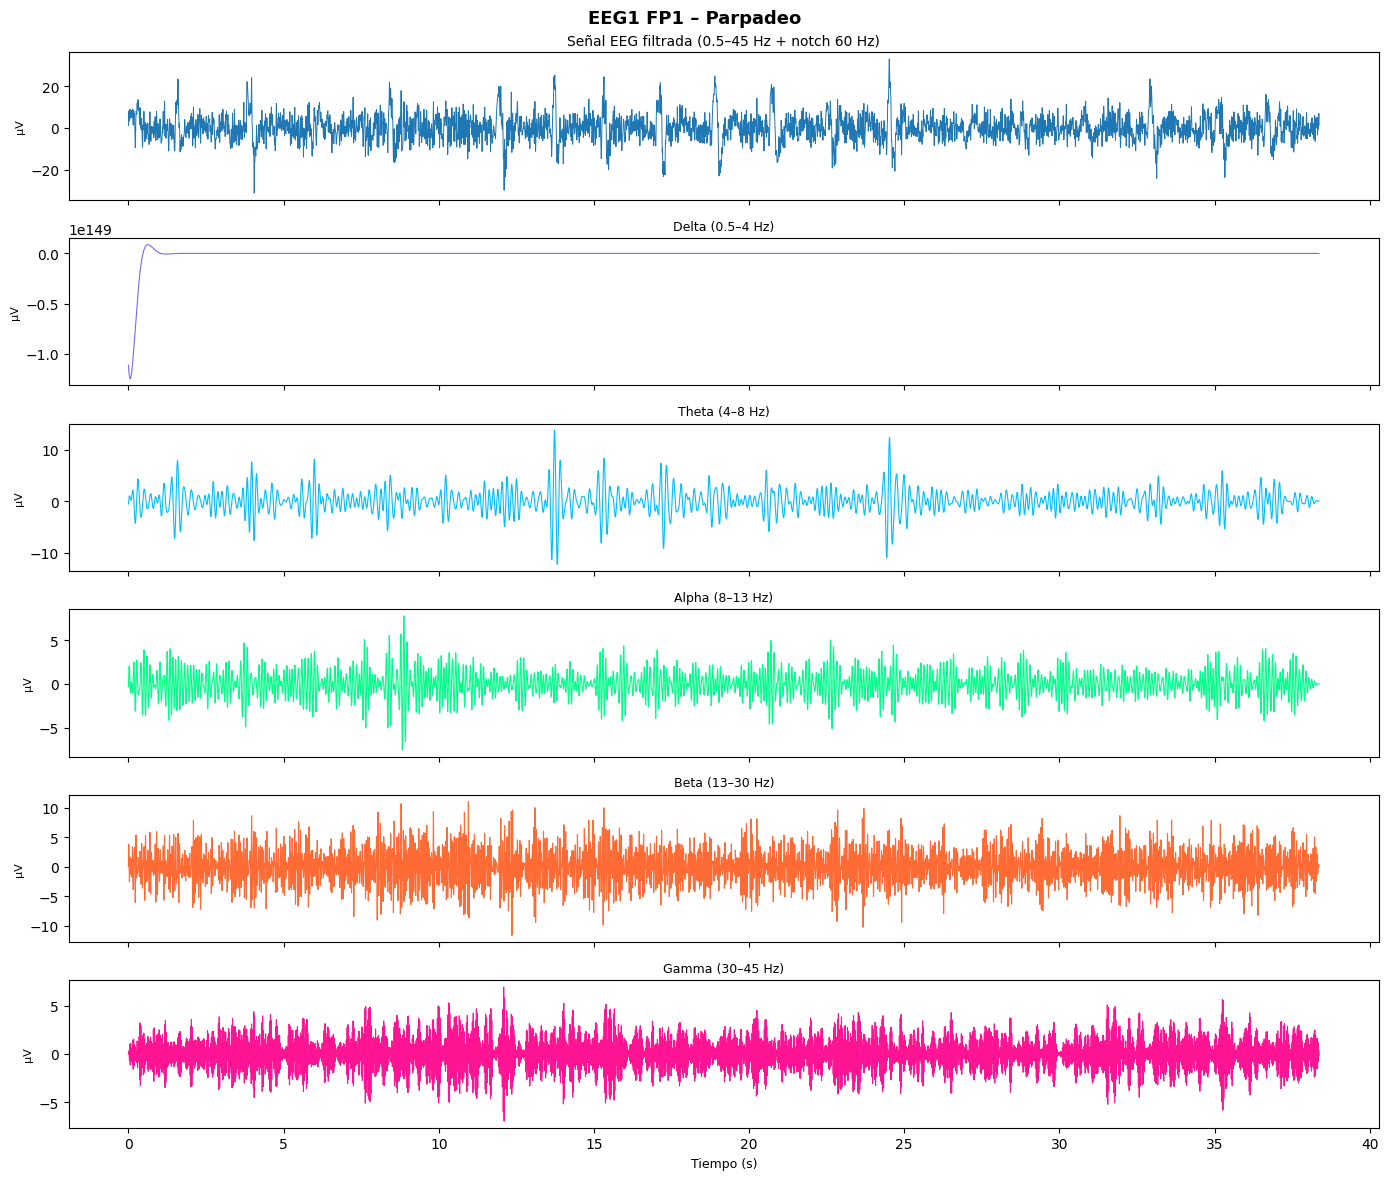

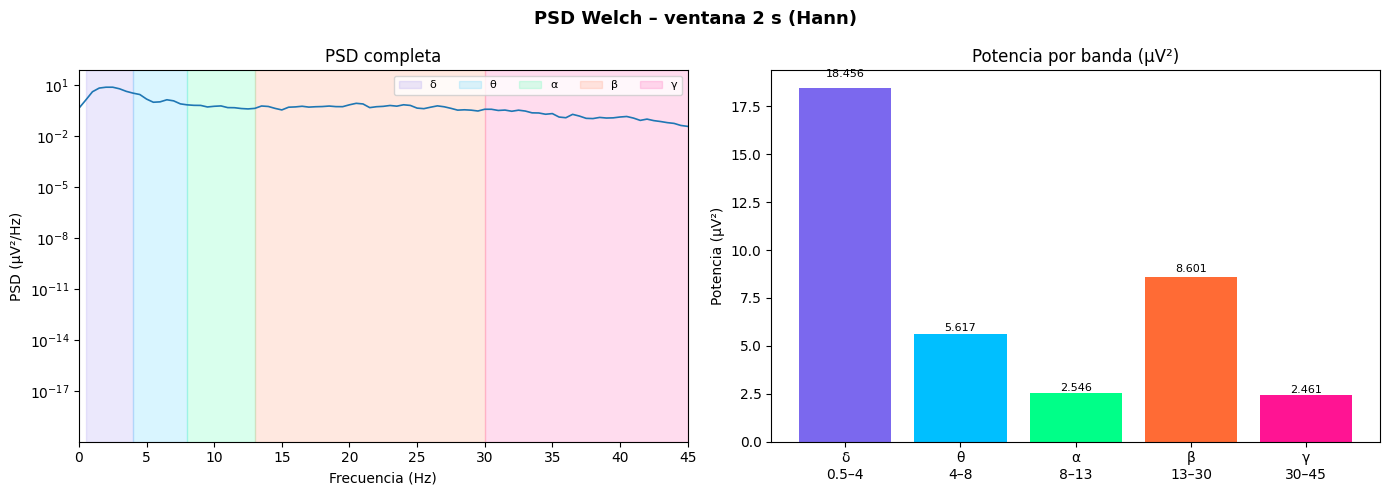

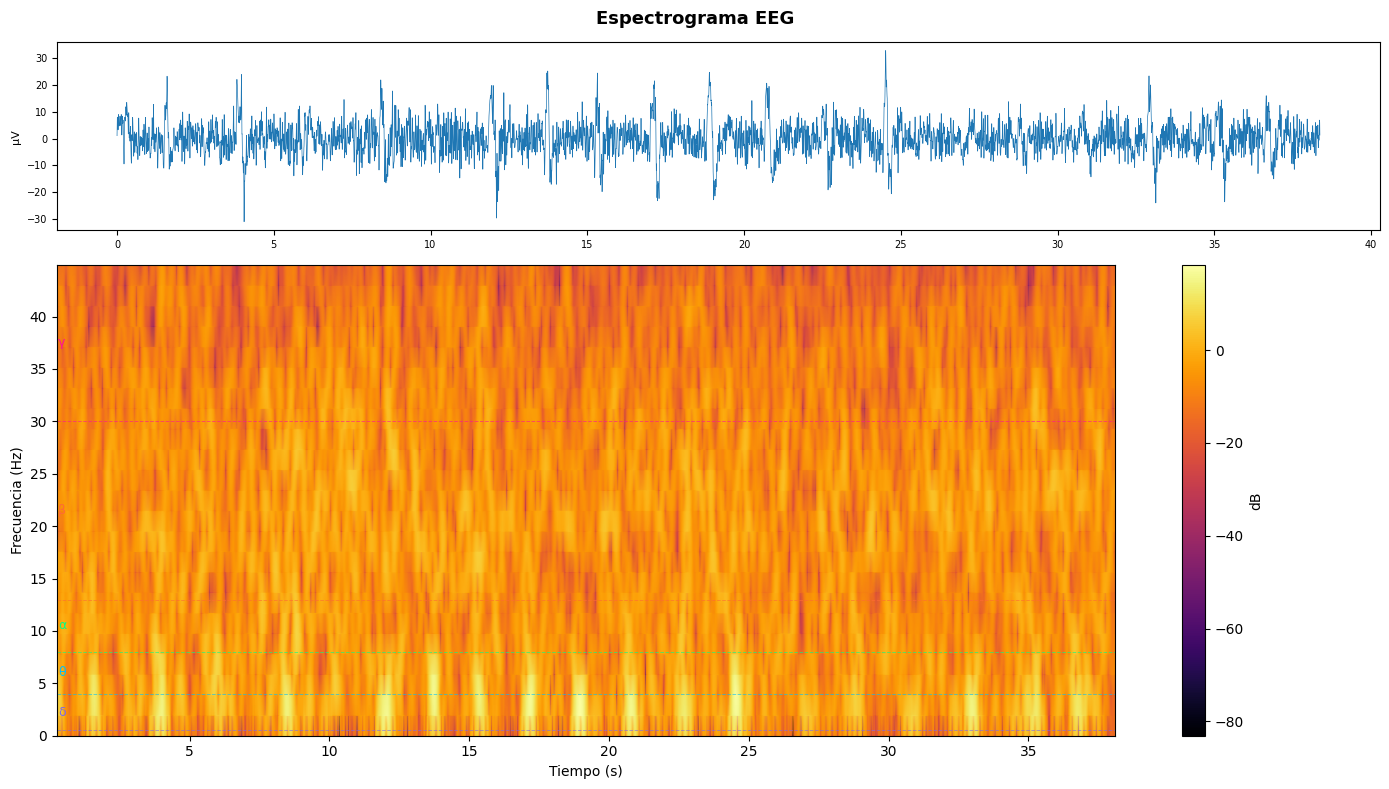

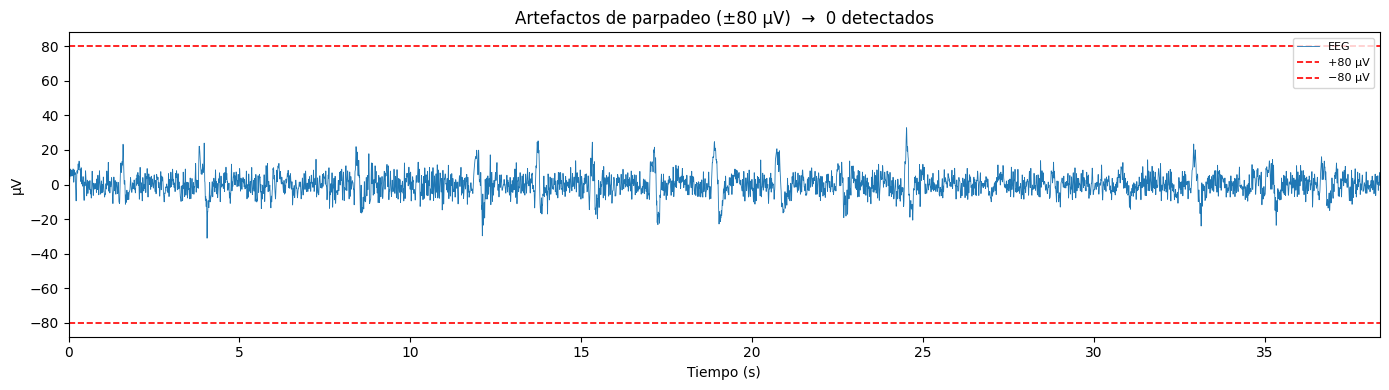

  RESUMEN – EEG1 Parpadeo
  Duración        : 38.37 s
  Rango señal     : -31.02 – 32.88 µV

  Delta (0.5–4 Hz)      : 18.4560 µV²  (49.0%)
  Theta (4–8 Hz)        : 5.6170 µV²  (14.9%)
  Alpha (8–13 Hz)       : 2.5459 µV²  (6.8%)
  Beta (13–30 Hz)       : 8.6008 µV²  (22.8%)
  Gamma (30–45 Hz)      : 2.4611 µV²  (6.5%)

  Parpadeos > 80 µV : 0


In [25]:


ARCHIVO   = "EEG2_Parpadeo.txt"
FS        = 1000    # Hz
VCC       = 3.3
GAIN      = 41782
BITS      = 10
BLINK_THR = 80      # µV

DARK  = '#0a0a14'
PANEL = '#12122a'
GRIDC = '#1e1e3a'

raw  = np.loadtxt(ARCHIVO, comments='#')
col  = raw[:, -1]
col  = col[col != 0]
eeg  = ((col / (2**BITS)) - 0.5) * VCC / GAIN * 1e6

print(f"Duración : {len(eeg)/FS:.2f} s")
print(f"Rango    : {eeg.min():.2f} – {eeg.max():.2f} µV")

#eeg_f = eeg
eeg_f = notch(eeg)
eeg_f = bandpass(eeg_f, 0.5, 45)

t   = np.arange(len(eeg_f)) / FS
dur = len(eeg_f) / FS

fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'EEG1 FP1 – Parpadeo', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.7)
axes[0].set_title('Señal EEG filtrada (0.5–45 Hz + notch 60 Hz)', fontsize=10)
axes[0].set_ylabel('µV', fontsize=8)

for i, (name, (lo, hi, col)) in enumerate(BANDS.items()):
    axes[i+1].plot(t, bandpass(eeg_f, lo, hi), color=col, lw=0.8)
    axes[i+1].set_title(name, fontsize=9)
    axes[i+1].set_ylabel('µV', fontsize=8)

axes[-1].set_xlabel('Tiempo (s)', fontsize=9)
plt.tight_layout()
plt.show()


NPERSEG = 2 * FS
f_w, psd_w = signal.welch(eeg_f, fs=FS, nperseg=NPERSEG,
                           noverlap=NPERSEG//2, window='hann')

def band_power(fmin, fmax):
    idx = (f_w >= fmin) & (f_w <= fmax)
    return np.trapezoid(psd_w[idx], f_w[idx])

powers = {n: band_power(lo, hi) for n, (lo, hi, _) in BANDS.items()}

regions = [(0.5,4,'#7b68ee','δ'),(4,8,'#00bfff','θ'),(8,13,'#00ff88','α'),
           (13,30,'#ff6b35','β'),(30,45,'#ff1493','γ')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PSD Welch – ventana 2 s (Hann)', fontsize=13, fontweight='bold')

axes[0].semilogy(f_w, psd_w, lw=1.2)
for lo, hi, col, lbl in regions:
    axes[0].axvspan(lo, hi, alpha=0.15, color=col, label=lbl)
axes[0].set_xlim(0, 45)
axes[0].set_xlabel('Frecuencia (Hz)')
axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].set_title('PSD completa')
axes[0].legend(ncol=5, fontsize=8)

labels = ['δ\n0.5–4','θ\n4–8','α\n8–13','β\n13–30','γ\n30–45']
cols_b = ['#7b68ee','#00bfff','#00ff88','#ff6b35','#ff1493']
vals   = list(powers.values())
bars   = axes[1].bar(labels, vals, color=cols_b)
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.03,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].set_title('Potencia por banda (µV²)')
axes[1].set_ylabel('Potencia (µV²)')

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                          gridspec_kw={'height_ratios': [1, 2.5]})
fig.suptitle('Espectrograma EEG', fontsize=13, fontweight='bold')

axes[0].plot(t, eeg_f, lw=0.5)
axes[0].set_ylabel('µV', fontsize=8)
axes[0].tick_params(labelsize=7)

f_sg, t_sg, Sxx = signal.spectrogram(eeg_f, fs=FS, nperseg=512,
                                      noverlap=480, window='hann')
idx_f = f_sg <= 45
im = axes[1].pcolormesh(t_sg, f_sg[idx_f],
                         10*np.log10(Sxx[idx_f]+1e-12),
                         cmap='inferno', shading='gouraud')
for lo, hi, col, lbl in regions:
    axes[1].axhline(lo, color=col, lw=0.7, ls='--', alpha=0.6)
    axes[1].text(0.3, (lo+hi)/2, lbl, color=col, fontsize=9, va='center')
axes[1].set_ylabel('Frecuencia (Hz)')
axes[1].set_xlabel('Tiempo (s)')
plt.colorbar(im, ax=axes[1], label='dB')

plt.tight_layout()
plt.show()


above = np.where(np.abs(eeg_f) > BLINK_THR)[0]
blink_idx, blink_amp = [], []
if len(above):
    min_gap = int(0.15 * FS)
    grp = [above[0]]
    for idx in above[1:]:
        if idx - grp[-1] <= min_gap:
            grp.append(idx)
        else:
            blink_idx.append(grp[0])
            blink_amp.append(np.max(np.abs(eeg_f[grp])))
            grp = [idx]
    blink_idx.append(grp[0])
    blink_amp.append(np.max(np.abs(eeg_f[grp])))

blink_idx = np.array(blink_idx)
blink_amp = np.array(blink_amp)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, eeg_f, lw=0.6, label='EEG')
ax.axhline( BLINK_THR, color='red', lw=1.2, ls='--', label=f'+{BLINK_THR} µV')
ax.axhline(-BLINK_THR, color='red', lw=1.2, ls='--', label=f'−{BLINK_THR} µV')
if len(blink_idx):
    ax.scatter(blink_idx/FS, eeg_f[blink_idx], color='orange',
               zorder=6, s=60, marker='v', label=f'{len(blink_idx)} parpadeos')
ax.set_title(f'Artefactos de parpadeo (±{BLINK_THR} µV)  →  {len(blink_idx)} detectados')
ax.set_xlabel('Tiempo (s)')
ax.set_ylabel('µV')
ax.set_xlim(t[0], t[-1])
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


total = sum(vals)
print("=" * 55)
print(f"  RESUMEN – EEG1 Parpadeo")
print("=" * 55)
print(f"  Duración        : {dur:.2f} s")
print(f"  Rango señal     : {eeg_f.min():.2f} – {eeg_f.max():.2f} µV")
print()
for name, val in powers.items():
    print(f"  {name:22s}: {val:.4f} µV²  ({val/total*100:.1f}%)")
print(f"\n  Parpadeos > {BLINK_THR} µV : {len(blink_idx)}")
if len(blink_amp):
    print(f"  Amplitud máxima  : {blink_amp.max():.2f} µV")
print("=" * 55)